In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv("/kaggle/input/datasets/suhanigupta04/student-placement-prediction-dataset/student_placement_synthetic.csv")



print("Shape (rows, columns):", df.shape)
print("\nColumn Names:\n", df.columns.tolist())
print("\nData Types:\n", df.dtypes)
print("\nMissing Values:\n", df.isnull().sum())
print("\nBasic Statistics:")
df.describe()

Shape (rows, columns): (100000, 18)

Column Names:
 ['branch', 'college_tier', 'cgpa', 'backlogs', 'coding_skills', 'dsa_score', 'aptitude_score', 'communication_skills', 'ml_knowledge', 'system_design', 'internships', 'projects_count', 'certifications', 'hackathons', 'open_source_contributions', 'extracurriculars', 'placement_status', 'salary_package_lpa']

Data Types:
 branch                        object
college_tier                  object
cgpa                         float64
backlogs                       int64
coding_skills                float64
dsa_score                    float64
aptitude_score               float64
communication_skills         float64
ml_knowledge                 float64
system_design                float64
internships                    int64
projects_count                 int64
certifications                 int64
hackathons                     int64
open_source_contributions      int64
extracurriculars               int64
placement_status               int

,cgpa,backlogs,coding_skills,dsa_score,aptitude_score,communication_skills,ml_knowledge,system_design,internships,projects_count,certifications,hackathons,open_source_contributions,extracurriculars,placement_status,salary_package_lpa
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,68475.000000
mean,7.206381,0.547010,5.995147,5.500711,64.990511,5.990614,4.508752,4.008210,1.095040,2.397280,1.49985,0.745840,0.450990,1.151100,0.684750,17.308014
std,0.925235,0.862727,1.496302,1.781961,11.990892,1.496552,1.968278,1.778405,0.940264,1.242829,1.11407,0.884189,0.671061,0.965162,0.464618,2.601041
min,4.000000,0.000000,1.000000,1.000000,20.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,6.880000
25%,6.580000,0.000000,5.000000,4.300000,56.800000,5.000000,3.200000,2.800000,0.000000,1.000000,1.00000,0.000000,0.000000,0.000000,0.000000,15.530000
50%,7.210000,0.000000,6.000000,5.500000,65.000000,6.000000,4.500000,4.000000,1.000000,2.000000,1.00000,0.000000,0.000000,1.000000,1.000000,17.250000
75%,7.830000,1.000000,7.000000,6.700000,73.100000,7.000000,5.900000,5.200000,2.000000,3.000000,2.00000,1.000000,1.000000,2.000000,1.000000,19.040000
max,10.000000,3.000000,10.000000,10.000000,100.000000,10.000000,10.000000,10.000000,3.000000,5.000000,4.00000,3.000000,2.000000,3.000000,1.000000,28.330000


/tmp/ipykernel_16/4232215394.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='placement_status', data=df, palette='Set2')
/tmp/ipykernel_16/4232215394.py:3: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Not Placed (0)', 'Placed (1)'])


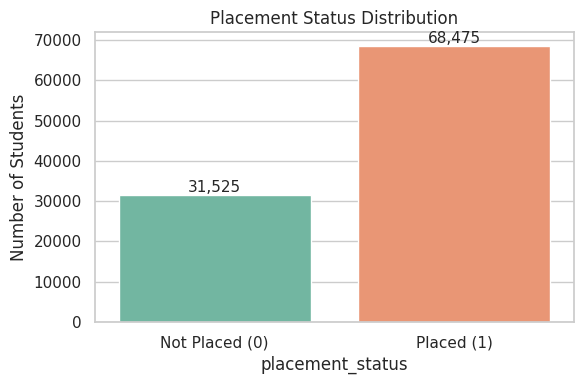

In [2]:

plt.figure(figsize=(6, 4))
ax = sns.countplot(x='placement_status', data=df, palette='Set2')
ax.set_xticklabels(['Not Placed (0)', 'Placed (1)'])
plt.title('Placement Status Distribution')
plt.ylabel('Number of Students')
for p in ax.patches:
    ax.annotate(f'{int(p.get_height()):,}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

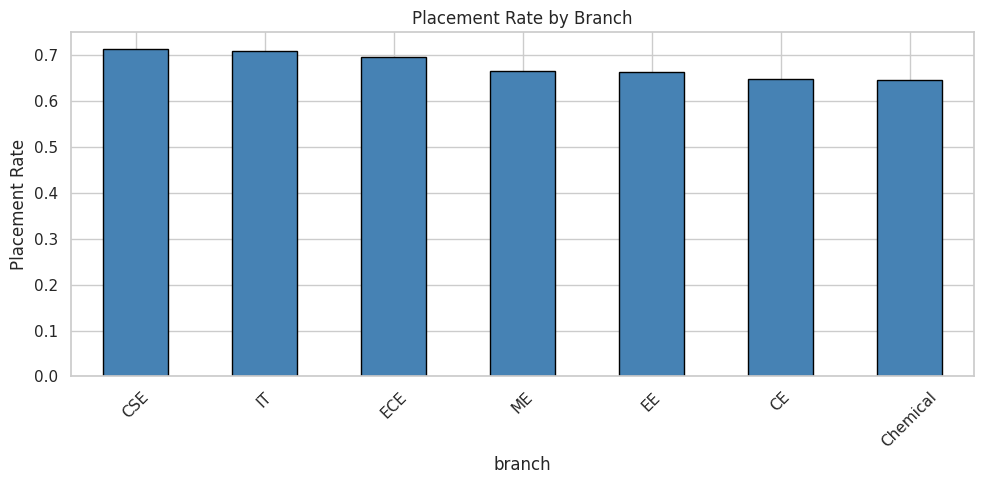

In [3]:

branch_placement = df.groupby('branch')['placement_status'].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 5))
branch_placement.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Placement Rate by Branch')
plt.ylabel('Placement Rate')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

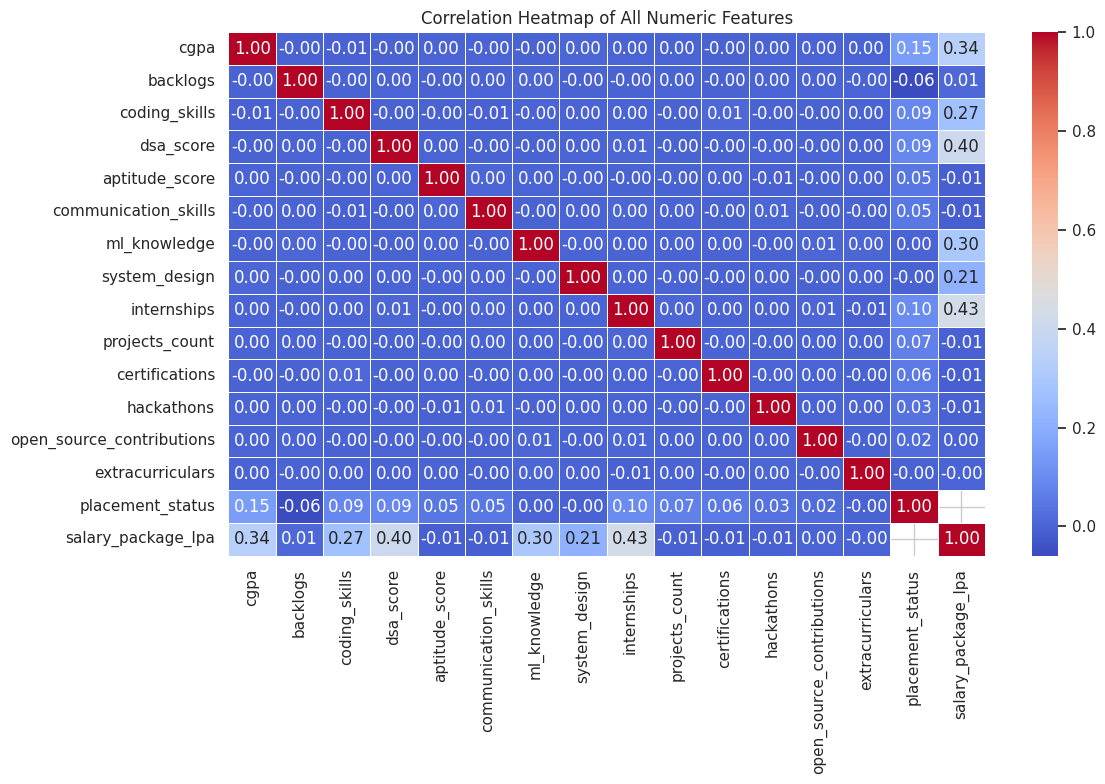

In [4]:

numeric_df = df.select_dtypes(include=np.number)
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of All Numeric Features')
plt.tight_layout()
plt.show()

In [5]:
pip install scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [6]:
# Data Preprocessing
from sklearn.preprocessing import LabelEncoder

df_model = df.copy()  # Always work on a copy, keep original safe

# Label Encoding for college_tier (it has order: Tier-1 > Tier-2 > Tier-3)
tier_map = {'Tier-1': 3, 'Tier-2': 2, 'Tier-3': 1}
df_model['college_tier'] = df_model['college_tier'].map(tier_map)

# One-Hot Encoding for branch (no order between branches)
df_model = pd.get_dummies(df_model, columns=['branch'], drop_first=True)

print("New shape after encoding:", df_model.shape)
print(df_model.head(3))

New shape after encoding: (100000, 23)
   college_tier  cgpa  backlogs  coding_skills  dsa_score  aptitude_score  \
0             1  6.70         0            7.6        4.4            49.5   
1             2  5.70         0            5.4        7.9            72.0   
2             2  7.19         0            5.6        6.8            79.1   

   communication_skills  ml_knowledge  system_design  internships  ...  \
0                   3.7           6.4            0.3            1  ...   
1                   8.3           6.3            1.9            0  ...   
2                   7.4           4.4            5.2            1  ...   

   open_source_contributions  extracurriculars  placement_status  \
0                          2                 1                 1   
1                          0                 0                 0   
2                          2                 0                 1   

   salary_package_lpa  branch_CSE  branch_Chemical  branch_ECE  branch_EE  \
0    

In [7]:
# ============================================================
# Task 1 (Classification): Predict placement_status (0 or 1)
# Task 2 (Regression):     Predict salary (only for placed students)
# ============================================================

# --- Task 1: Classification ---
# Features (X) = everything except placement_status and salary
# Target  (y) = placement_status

X_cls = df_model.drop(columns=['placement_status', 'salary_package_lpa'])
y_cls = df_model['placement_status']

# --- Task 2: Regression ---
# Only use rows where student was placed (placement_status == 1)
# Target (y) = salary_package_lpa

placed_df = df_model[df_model['placement_status'] == 1].copy()
X_reg = placed_df.drop(columns=['placement_status', 'salary_package_lpa'])
y_reg = placed_df['salary_package_lpa']

print("Classification - X shape:", X_cls.shape, "| y shape:", y_cls.shape)
print("Regression    - X shape:", X_reg.shape, "| y shape:", y_reg.shape)

Classification - X shape: (100000, 21) | y shape: (100000,)
Regression    - X shape: (68475, 21) | y shape: (68475,)


In [8]:
from sklearn.model_selection import train_test_split

# Split data: 80% for training the model, 20% for testing it
# random_state=42 means we get the same split every time we run

# Classification split
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=0.2, random_state=42, stratify=y_cls
)
# Note: stratify=y_cls ensures same placement ratio in train and test sets

# Regression split
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print("Classification Train:", X_train_cls.shape, "| Test:", X_test_cls.shape)
print("Regression    Train:", X_train_reg.shape, "| Test:", X_test_reg.shape)

Classification Train: (80000, 21) | Test: (20000, 21)
Regression    Train: (54780, 21) | Test: (13695, 21)


In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_cls_sc = scaler.fit_transform(X_train_cls)  # fit + transform on train
X_test_cls_sc  = scaler.transform(X_test_cls)        # only transform on test

# Save a separate scaler for regression
scaler_reg = StandardScaler()
X_train_reg_sc = scaler_reg.fit_transform(X_train_reg)
X_test_reg_sc  = scaler_reg.transform(X_test_reg)

print("✅ Scaling done! Data is ready for modelling.")

✅ Scaling done! Data is ready for modelling.


In [10]:
# ============================================================
# Classification Models
# We train 3 different algorithms and compare them
# ============================================================

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
import time

# --- Model 1: Logistic Regression ---

print("Training Logistic Regression...")
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_cls_sc, y_train_cls)
lr_preds = lr.predict(X_test_cls_sc)
print(f"✅ Logistic Regression Accuracy: {accuracy_score(y_test_cls, lr_preds)*100:.2f}%\n")

# --- Model 2: Random Forest ---

print("Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_cls, y_train_cls)   # Tree models don't need scaled data
rf_preds = rf.predict(X_test_cls)
print(f"✅ Random Forest Accuracy: {accuracy_score(y_test_cls, rf_preds)*100:.2f}%\n")

# --- Model 3: Gradient Boosting ---

print("Training Gradient Boosting...")
gb = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb.fit(X_train_cls, y_train_cls)
gb_preds = gb.predict(X_test_cls)
print(f"✅ Gradient Boosting Accuracy: {accuracy_score(y_test_cls, gb_preds)*100:.2f}%\n")

Training Logistic Regression...
✅ Logistic Regression Accuracy: 69.94%

Training Random Forest...
✅ Random Forest Accuracy: 69.29%

Training Gradient Boosting...
✅ Gradient Boosting Accuracy: 69.87%



In [11]:
# ============================================================
# Compare all 3 models side by side
# ============================================================

models_cls = {
    'Logistic Regression': lr_preds,
    'Random Forest':       rf_preds,
    'Gradient Boosting':   gb_preds
}

print("=" * 55)
print(f"{'Model':<25} {'Accuracy':>10} {'Best?':>10}")
print("=" * 55)
for name, preds in models_cls.items():
    acc = accuracy_score(y_test_cls, preds) * 100
    print(f"{name:<25} {acc:>9.2f}% {'⭐' if acc == max(accuracy_score(y_test_cls, p)*100 for p in models_cls.values()) else ''}")
print("=" * 55)


Model                       Accuracy      Best?
Logistic Regression           69.94% ⭐
Random Forest                 69.29% 
Gradient Boosting             69.87% 


📋 Detailed Classification Report — Random Forest
              precision    recall  f1-score   support

  Not Placed       0.54      0.18      0.27      6305
      Placed       0.71      0.93      0.81     13695

    accuracy                           0.69     20000
   macro avg       0.62      0.56      0.54     20000
weighted avg       0.66      0.69      0.64     20000



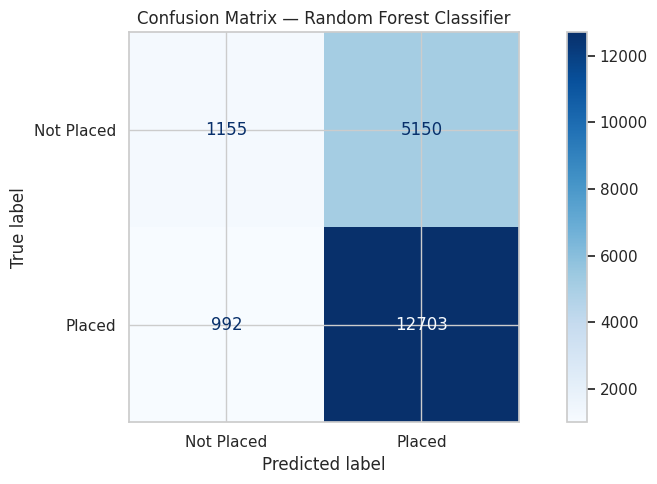

In [12]:
# ============================================================
# Classification Report breaks down performance per class
# Precision: Of all predicted "Placed", how many actually were?
# Recall:    Of all actual "Placed", how many did we catch?
# F1-Score:  Balance between Precision and Recall
# ============================================================

print("📋 Detailed Classification Report — Random Forest")
print(classification_report(y_test_cls, rf_preds,
                            target_names=['Not Placed', 'Placed']))

# Confusion Matrix — shows where the model made mistakes
cm = confusion_matrix(y_test_cls, rf_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Not Placed', 'Placed'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix — Random Forest Classifier')
plt.tight_layout()
plt.show()

/tmp/ipykernel_16/3706491072.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')


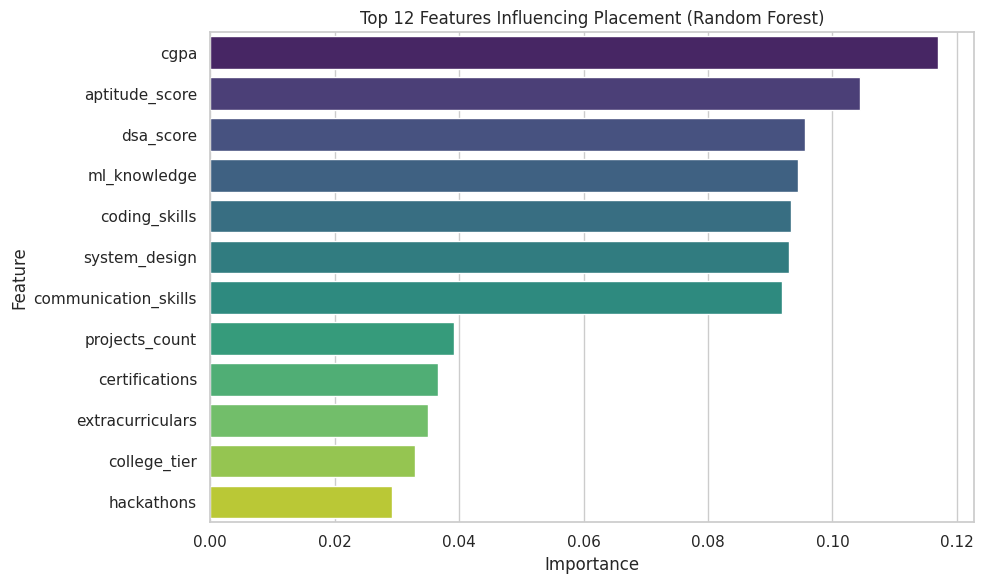

In [13]:
# ============================================================
# Feature Importance tells us WHICH features the model
# relied on most to make predictions
# ============================================================

feature_names = X_cls.columns.tolist()
importances = rf.feature_importances_

feat_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_df = feat_df.sort_values('Importance', ascending=False).head(12)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feat_df, palette='viridis')
plt.title('Top 12 Features Influencing Placement (Random Forest)')
plt.tight_layout()
plt.show()

In [14]:
# ============================================================
# STEP 4b: Regression Models
# Predict the actual salary package (a number, not a category)
# ============================================================

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, r2_score

# --- Model 1: Linear Regression ---
# Draws the best straight line through the data
print("Training Linear Regression...")
lr_reg = LinearRegression()
lr_reg.fit(X_train_reg_sc, y_train_reg)
lr_reg_preds = lr_reg.predict(X_test_reg_sc)

# --- Model 2: Random Forest Regressor ---
print("Training Random Forest Regressor...")
rf_reg = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_reg.fit(X_train_reg, y_train_reg)
rf_reg_preds = rf_reg.predict(X_test_reg)

# --- Model 3: Gradient Boosting Regressor ---
print("Training Gradient Boosting Regressor...")
gb_reg = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb_reg.fit(X_train_reg, y_train_reg)
gb_reg_preds = gb_reg.predict(X_test_reg)

print("\n✅ All regression models trained!")

Training Linear Regression...
Training Random Forest Regressor...
Training Gradient Boosting Regressor...

✅ All regression models trained!


In [15]:
# ============================================================
# MAE  = Mean Absolute Error: average rupee error in prediction
# R²   = How much variance the model explains (1.0 = perfect)
# ============================================================

reg_models = {
    'Linear Regression':      (lr_reg_preds,  "scaled"),
    'Random Forest Reg':      (rf_reg_preds,  "raw"),
    'Gradient Boosting Reg':  (gb_reg_preds,  "raw"),
}

print("=" * 60)
print(f"{'Model':<26} {'MAE (LPA)':>12} {'R² Score':>12}")
print("=" * 60)
for name, (preds, _) in reg_models.items():
    mae = mean_absolute_error(y_test_reg, preds)
    r2  = r2_score(y_test_reg, preds)
    print(f"{name:<26} {mae:>11.4f}  {r2:>11.4f}")
print("=" * 60)

Model                         MAE (LPA)     R² Score
Linear Regression               0.9869       0.7734
Random Forest Reg               1.0139       0.7601
Gradient Boosting Reg           0.9704       0.7798


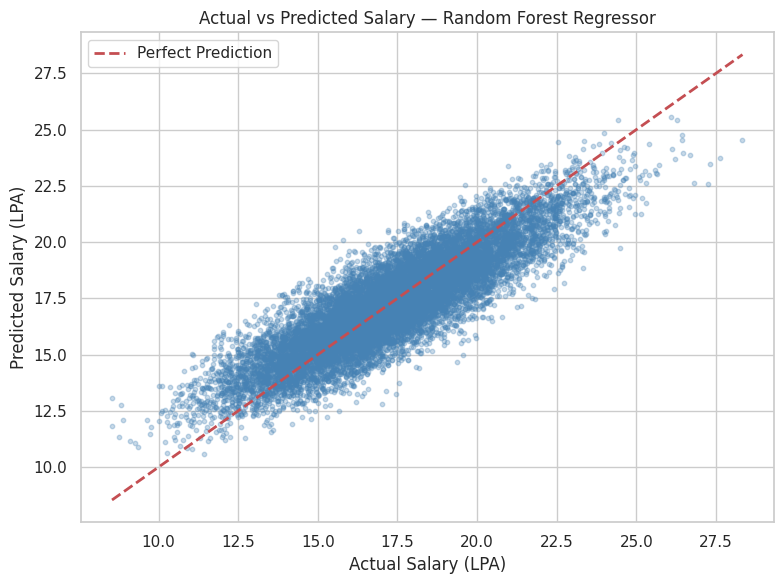

In [16]:
# ============================================================
# Scatter plot: if predictions were perfect, all dots would
# fall exactly on the diagonal red line
# ============================================================

plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, rf_reg_preds, alpha=0.3, color='steelblue', s=10)
plt.plot([y_test_reg.min(), y_test_reg.max()],
         [y_test_reg.min(), y_test_reg.max()],
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Salary (LPA)')
plt.ylabel('Predicted Salary (LPA)')
plt.title('Actual vs Predicted Salary — Random Forest Regressor')
plt.legend()
plt.tight_layout()
plt.show()

In [17]:

import joblib

joblib.dump(rf,        'placement_classifier.pkl')   # Classification model
joblib.dump(rf_reg,    'salary_regressor.pkl')        # Regression model
joblib.dump(scaler,    'scaler_classifier.pkl')       # Scaler for classification
joblib.dump(scaler_reg,'scaler_regressor.pkl')        # Scaler for regression

# Saving the column names — needed when predicting on new data
joblib.dump(X_cls.columns.tolist(), 'feature_columns.pkl')

print("✅ All models saved successfully!")
print("Files created:")
print("  📦 placement_classifier.pkl")
print("  📦 salary_regressor.pkl")
print("  📦 scaler_classifier.pkl")
print("  📦 scaler_regressor.pkl")
print("  📦 feature_columns.pkl")

✅ All models saved successfully!
Files created:
  📦 placement_classifier.pkl
  📦 salary_regressor.pkl
  📦 scaler_classifier.pkl
  📦 scaler_regressor.pkl
  📦 feature_columns.pkl


In [18]:
# ============================================================
# This function takes a new student's details and predicts:
# 1. Will they get placed? (Yes/No)
# 2. If yes, what salary can they expect?
# ============================================================

def predict_student(student_dict):
    """
    Input : a dictionary of one student's details
    Output: placement prediction + expected salary
    """

    # Load saved models
    clf        = joblib.load('placement_classifier.pkl')
    reg        = joblib.load('salary_regressor.pkl')
    feat_cols  = joblib.load('feature_columns.pkl')

    # Step 1: Converting input dict to DataFrame
    input_df = pd.DataFrame([student_dict])

    # Step 2: Encode college_tier
    tier_map = {'Tier-1': 3, 'Tier-2': 2, 'Tier-3': 1}
    input_df['college_tier'] = input_df['college_tier'].map(tier_map)

    # Step 3: One-hot encode branch
    input_df = pd.get_dummies(input_df, columns=['branch'], drop_first=True)

    # Step 4: Adding any missing columns (with value 0) to match training data
    for col in feat_cols:
        if col not in input_df.columns:
            input_df[col] = 0

    # Step 5: Reorder columns to exactly match training order
    input_df = input_df[feat_cols]

    # Step 6: Predict placement
    placement = clf.predict(input_df)[0]
    placement_prob = clf.predict_proba(input_df)[0][1] * 100

    print("=" * 45)
    print("       🎓 STUDENT PLACEMENT PREDICTION")
    print("=" * 45)

    if placement == 1:
        salary = reg.predict(input_df)[0]
        print(f"  ✅ Placement Status  : PLACED")
        print(f"  📊 Placement Chance  : {placement_prob:.1f}%")
        print(f"  💰 Expected Salary   : ₹ {salary:.2f} LPA")
    else:
        print(f"  ❌ Placement Status  : NOT PLACED")
        print(f"  📊 Placement Chance  : {placement_prob:.1f}%")
        print(f"  💡 Tip: Improve coding skills, DSA & get internships!")

    print("=" * 45)

In [19]:
# ============================================================
# Try predicting for different student profiles
# ============================================================

# --- Student 1: Strong CSE student ---
student_1 = {
    'college_tier':             'Tier-1',
    'branch':                   'CSE',
    'cgpa':                      8.9,
    'backlogs':                  0,
    'coding_skills':             9.0,
    'dsa_score':                 8.5,
    'aptitude_score':            8.0,
    'communication_skills':      8.5,
    'ml_knowledge':              7.5,
    'system_design':             7.0,
    'internships':               2,
    'projects_count':            4,
    'certifications':            3,
    'hackathons':                2,
    'open_source_contributions': 1,
    'extracurriculars':          2
}

# --- Student 2: Average student with backlogs ---
student_2 = {
    'college_tier':             'Tier-3',
    'branch':                   'ME',
    'cgpa':                      5.8,
    'backlogs':                  3,
    'coding_skills':             4.0,
    'dsa_score':                 3.5,
    'aptitude_score':            5.0,
    'communication_skills':      5.0,
    'ml_knowledge':              2.0,
    'system_design':             2.5,
    'internships':               0,
    'projects_count':            1,
    'certifications':            0,
    'hackathons':                0,
    'open_source_contributions': 0,
    'extracurriculars':          1
}

# --- Student 3: Good student but non-CS branch ---
student_3 = {
    'college_tier':             'Tier-2',
    'branch':                   'ECE',
    'cgpa':                      7.8,
    'backlogs':                  0,
    'coding_skills':             7.0,
    'dsa_score':                 6.5,
    'aptitude_score':            7.5,
    'communication_skills':      8.0,
    'ml_knowledge':              5.0,
    'system_design':             5.5,
    'internships':               1,
    'projects_count':            3,
    'certifications':            2,
    'hackathons':                1,
    'open_source_contributions': 0,
    'extracurriculars':          2
}

print(">>> STUDENT 1: Strong CSE from Tier-1")
predict_student(student_1)

print("\n>>> STUDENT 2: Average ME from Tier-3")
predict_student(student_2)

print("\n>>> STUDENT 3: ECE from Tier-2")
predict_student(student_3)

>>> STUDENT 1: Strong CSE from Tier-1
       🎓 STUDENT PLACEMENT PREDICTION
  ✅ Placement Status  : PLACED
  📊 Placement Chance  : 79.0%
  💰 Expected Salary   : ₹ 25.40 LPA

>>> STUDENT 2: Average ME from Tier-3
       🎓 STUDENT PLACEMENT PREDICTION
  ❌ Placement Status  : NOT PLACED
  📊 Placement Chance  : 34.0%
  💡 Tip: Improve coding skills, DSA & get internships!

>>> STUDENT 3: ECE from Tier-2
       🎓 STUDENT PLACEMENT PREDICTION
  ✅ Placement Status  : PLACED
  📊 Placement Chance  : 77.0%
  💰 Expected Salary   : ₹ 18.19 LPA


In [20]:
# ============================================================
# Printing  a clean summary of everything that has been built
# ============================================================

from sklearn.metrics import accuracy_score, r2_score, mean_absolute_error

print("""
╔══════════════════════════════════════════════════════╗
║         🎓 ML PROJECT — FINAL SUMMARY                ║
╠══════════════════════════════════════════════════════╣
║  Dataset   : 1,00,000 students | 18 features         ║
║  Tasks     : Classification + Regression             ║
╠══════════════════════════════════════════════════════╣
║  TASK 1 — Placement Prediction (Classification)      ║
║  Algorithm : Random Forest Classifier                ║
║  Accuracy  : {:.2f}%                                ║
╠══════════════════════════════════════════════════════╣
║  TASK 2 — Salary Prediction (Regression)             ║
║  Algorithm : Random Forest Regressor                 ║
║  R² Score  : {:.4f}                                 ║
║  MAE       : {:.4f} LPA                             ║
╠══════════════════════════════════════════════════════╣
║  Models saved as .pkl files — ready to reuse! 💾     ║
╚══════════════════════════════════════════════════════╝
""".format(
    accuracy_score(y_test_cls, rf_preds) * 100,
    r2_score(y_test_reg, rf_reg_preds),
    mean_absolute_error(y_test_reg, rf_reg_preds)
))


╔══════════════════════════════════════════════════════╗
║         🎓 ML PROJECT — FINAL SUMMARY                ║
╠══════════════════════════════════════════════════════╣
║  Dataset   : 1,00,000 students | 18 features         ║
║  Tasks     : Classification + Regression             ║
╠══════════════════════════════════════════════════════╣
║  TASK 1 — Placement Prediction (Classification)      ║
║  Algorithm : Random Forest Classifier                ║
║  Accuracy  : 69.29%                                ║
╠══════════════════════════════════════════════════════╣
║  TASK 2 — Salary Prediction (Regression)             ║
║  Algorithm : Random Forest Regressor                 ║
║  R² Score  : 0.7601                                 ║
║  MAE       : 1.0139 LPA                             ║
╠══════════════════════════════════════════════════════╣
║  Models saved as .pkl files — ready to reuse! 💾     ║
╚══════════════════════════════════════════════════════╝

